# 03 — Feature Engineering

Criação de variáveis derivadas para alimentar os modelos supervisionado e não supervisionado. Inclui período do dia, estação, feriados e o target binário de atraso (limiar FAA de 15 minutos).

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

import pandas as pd
import matplotlib.pyplot as plt

from voos.features import criar_features_completas, selecionar_features_modelo, codificar_categoricas
from voos.limpeza import salvar_parquet

CAMINHO_PARQUET = os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "voos_limpos.parquet")
df = pd.read_parquet(CAMINHO_PARQUET)
print(f"Dados carregados: {len(df):,} linhas x {len(df.columns)} colunas")

Dados carregados: 5,819,079 linhas x 31 colunas


## 1. Criação de features derivadas

Novas colunas: `PERIODO_DIA`, `ESTACAO`, `FERIADO`, `ATRASO_BINARIO` (1 se atraso >= 15 min).

In [2]:
df = criar_features_completas(df)
print(f"Novas colunas adicionadas: {[c for c in df.columns if c not in pd.read_parquet(CAMINHO_PARQUET).columns]}")
print(f"\nShape: {df.shape}")
df[["PERIODO_DIA", "ESTACAO", "FERIADO", "ATRASO_BINARIO"]].head(10)

Novas colunas adicionadas: ['PERIODO_DIA', 'ESTACAO', 'FERIADO', 'ATRASO_BINARIO']

Shape: (5819079, 35)


,PERIODO_DIA,ESTACAO,FERIADO,ATRASO_BINARIO
0,madrugada,inverno,True,0.0
1,madrugada,inverno,True,0.0
2,madrugada,inverno,True,0.0
3,madrugada,inverno,True,0.0
4,madrugada,inverno,True,0.0
5,madrugada,inverno,True,0.0
6,madrugada,inverno,True,0.0
7,madrugada,inverno,True,0.0
8,madrugada,inverno,True,0.0
9,madrugada,inverno,True,0.0


## 2. Distribuição das novas features

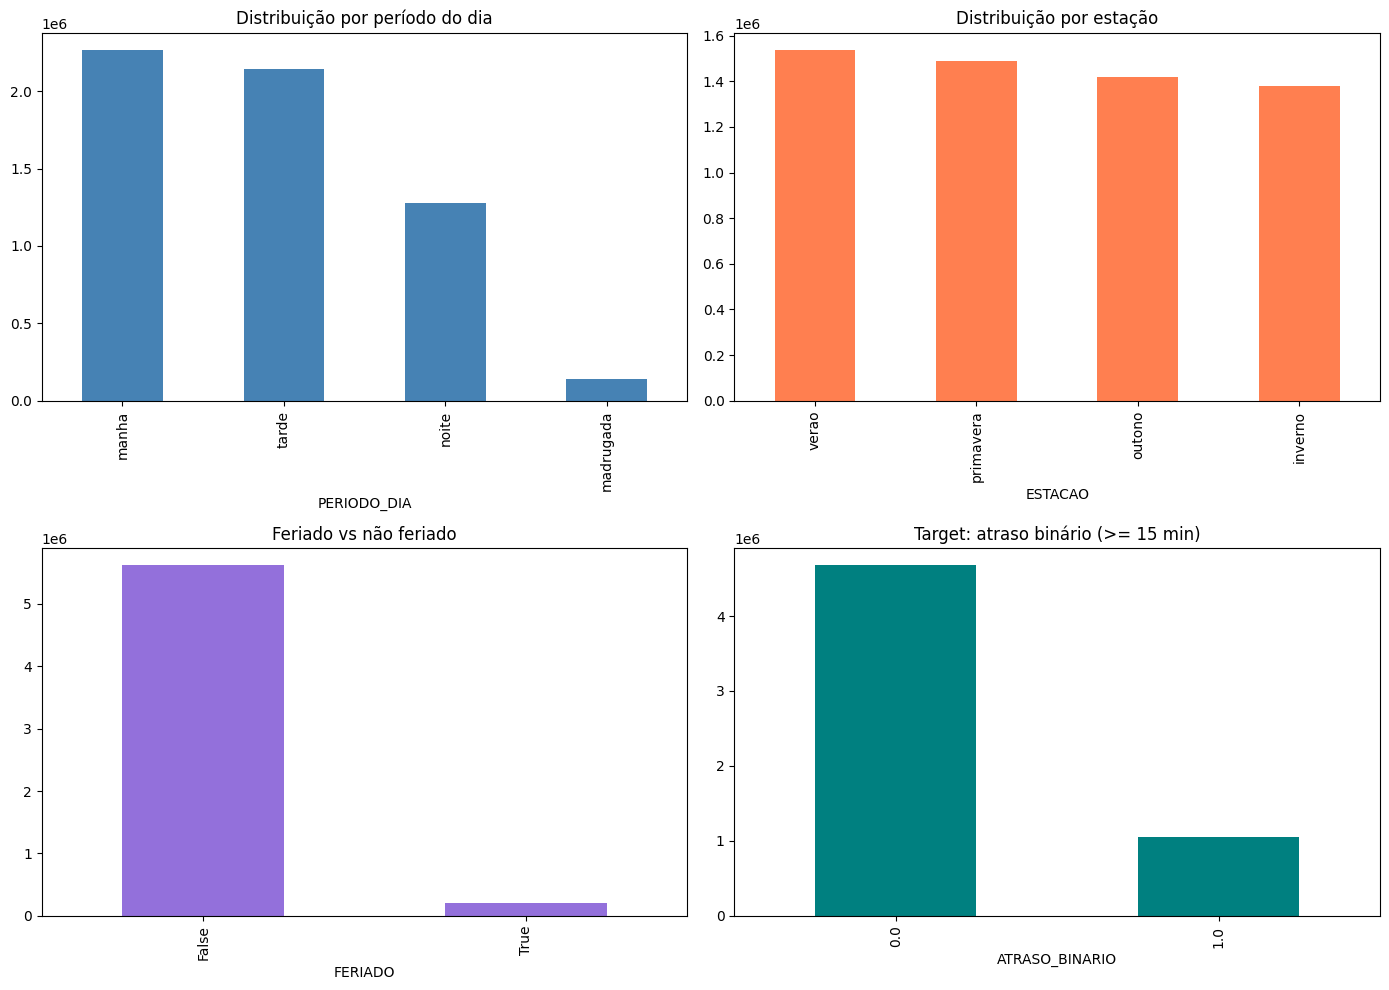


Proporção de voos atrasados: 18.45%


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["PERIODO_DIA"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribuição por período do dia")

df["ESTACAO"].value_counts().plot(kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Distribuição por estação")

df["FERIADO"].value_counts().plot(kind="bar", ax=axes[1, 0], color="mediumpurple")
axes[1, 0].set_title("Feriado vs não feriado")

df["ATRASO_BINARIO"].value_counts().plot(kind="bar", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Target: atraso binário (>= 15 min)")

plt.tight_layout()
plt.show()

print(f"\nProporção de voos atrasados: {df['ATRASO_BINARIO'].mean():.2%}")

## 3. Seleção de features (sem data leakage)

Removemos colunas que não estariam disponíveis no momento da previsão (tempos reais de partida/chegada, breakdown de atrasos) e colunas sem valor preditivo (YEAR, FLIGHT_NUMBER, TAIL_NUMBER).

In [4]:
df_features = selecionar_features_modelo(df)
print(f"Features selecionadas ({len(df_features.columns)} colunas):")
print(list(df_features.columns))

Features selecionadas (13 colunas):
['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'PERIODO_DIA', 'ESTACAO', 'FERIADO']


## 4. Salvando dados com features

In [5]:
CAMINHO_FEATURES = os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "voos_features.parquet")
salvar_parquet(df, CAMINHO_FEATURES)
print(f"Dados com features salvos em: {CAMINHO_FEATURES}")
print(f"Shape final: {df.shape}")

Dados com features salvos em: /Users/nsx001191/Documents/fiap/fiap-tcf-3/data/processed/voos_features.parquet
Shape final: (5819079, 35)
